In [29]:
#Libraries
import pandas as pd
import os
import random
import numpy as np
import torch
from transformers import set_seed
from datasets import Dataset
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [17]:
#Load the dataset
train_df = pd.read_csv("/content/phishing_train.csv")
val_df = pd.read_csv("/content/phishing_validation.csv")
test_df = pd.read_csv("/content/phishing_test.csv")

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(14015, 4)
(1752, 4)
(1752, 4)


In [18]:
#Setup reproducibility
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

set_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed:", SEED)
print("GPU:", torch.cuda.get_device_name(0))

Seed: 42
GPU: NVIDIA A100-SXM4-40GB


In [19]:
#Convert dataset
train_dataset = Dataset.from_pandas(
    train_df[["processed_text", "label"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[["processed_text", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["processed_text", "label"]],
    preserve_index=False
)

In [20]:
#Load Model
MODEL_NAME = "distilbert/distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded: distilbert/distilbert-base-uncased


In [21]:
#Tokenise
MAX_LENGTH = 512

def tokenize_function(examples):
    return tokenizer(
        examples["processed_text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False
    )

train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["processed_text"]
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["processed_text"]
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["processed_text"]
)
print(train_tokenized)

Map:   0%|          | 0/14015 [00:00<?, ? examples/s]

Map:   0%|          | 0/1752 [00:00<?, ? examples/s]

Map:   0%|          | 0/1752 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 14015
})


In [22]:
#Load classification model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    torch_dtype=torch.float32
)

print("Model dtype:", next(model.parameters()).dtype)
print("DistilBERT loaded.")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model dtype: torch.float32
DistilBERT loaded.


In [24]:
#Evaluating matrix
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        pos_label=1,
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [26]:
#Setup configuration
training_args = TrainingArguments(
    output_dir="/content/distilbert_results",

    num_train_epochs=3,

    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,

    gradient_accumulation_steps=1,

    learning_rate=2e-5,
    weight_decay=0.01,

    warmup_steps=263,
    max_grad_norm=1.0,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    fp16=False,
    bf16=False,

    optim="adamw_torch",

    seed=42,
    data_seed=42,

    report_to="none",
    save_total_limit=2
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

print("DistilBERT Trainer ready.")

DistilBERT Trainer ready.


In [27]:
#Train Model
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.077392,0.060648,0.976027,0.954006,0.983180,0.968373
2,0.037536,0.072522,0.977740,0.950220,0.992355,0.970830
3,0.011074,0.055520,0.986872,0.987635,0.977064,0.982321


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [28]:
#Evaluate on Test set
test_results = trainer.evaluate(
    test_tokenized,
    metric_key_prefix="test"
)

print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.011074,0.030928,3,0.992009,0.989297,0.989297,0.989297


{'test_loss': 0.0309277530759573, 'test_accuracy': 0.9920091324200914, 'test_precision': 0.9892966360856269, 'test_recall': 0.9892966360856269, 'test_f1': 0.9892966360856269}


                precision    recall  f1-score   support

    Safe Email     0.9936    0.9936    0.9936      1098
Phishing Email     0.9893    0.9893    0.9893       654

      accuracy                         0.9920      1752
     macro avg     0.9915    0.9915    0.9915      1752
  weighted avg     0.9920    0.9920    0.9920      1752

Confusion Matrix:
[[1091    7]
 [   7  647]]


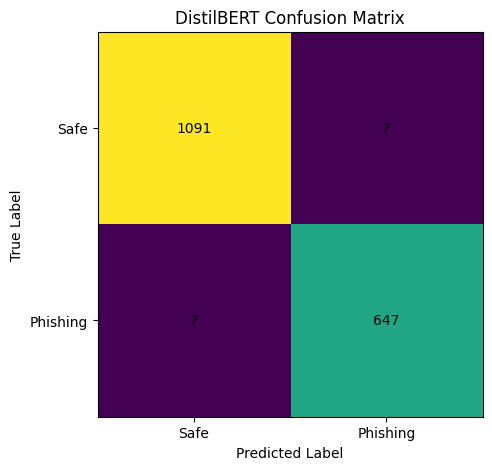

In [30]:
#Classification report and Confusion matrix
predictions = trainer.predict(test_tokenized)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print(classification_report(
    y_true,
    y_pred,
    target_names=["Safe Email", "Phishing Email"],
    digits=4
))

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("DistilBERT Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Safe", "Phishing"])
plt.yticks([0, 1], ["Safe", "Phishing"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()